In [1]:
from typing import Optional
import torch
from torch import nn
from torchaudio import functional as F
import torch.nn.functional as F_torch
import torchaudio.functional as TAF

class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        # STFT parameters
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.pad_mode = pad_mode
        self.power = power
        self.normalize_stft = normalize_stft
        self.onesided = onesided
        self.center = center
        self.return_complex = return_complex


        if f_max_hz is None:
            f_max_hz = samplerate / 2
        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale


        self.window_length = n_fft
        self.register_buffer("window", torch.hann_window(self.window_length))
        self.register_buffer("mel_fbanks", self._init_melscale_fbanks())

    def _init_melscale_fbanks(self):
        n_freqs = self.n_fft // 2 + 1 if self.onesided else self.n_fft

        return TAF.melscale_fbanks(
            n_freqs=n_freqs,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale
        )

    def spectrogram(self, x):
        return torch.stft(
            x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=self.window,
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex
        )

    def forward(self, x):
        # Вычисляем STFT
        spec = self.spectrogram(x)
        # Если форма не соответствует (batch, n_freq, n_frames), попробуем транспонировать оси
        # (иногда torch.stft возвращает (batch, n_frames, n_freq))
        if spec.dim() == 3 and spec.shape[1] != self.mel_fbanks.shape[1] and spec.shape[2] == self.mel_fbanks.shape[1]:
            spec = spec.transpose(1, 2)

        # Вычисляем power спектр
        spec_power = spec.abs() ** self.power  # (batch, n_freq, n_frames)

        # Если mel-фильтры имеют форму (n_freq, n_mels), то транспонируем их
        if self.mel_fbanks.shape[0] != self.n_mels:
            mel_fbanks = self.mel_fbanks.t()  # теперь должна быть (n_mels, n_freq)
        else:
            mel_fbanks = self.mel_fbanks

        # Проверим, что размерность по частотной оси совпадает
        # spec_power имеет размер n_freq в оси 1, а mel_fbanks должна иметь n_freq в оси 1
        assert spec_power.shape[1] == mel_fbanks.shape[1], \
            f"Mismatch: spec_power.shape[1]={spec_power.shape[1]}, mel_fbanks.shape[1]={mel_fbanks.shape[1]}"

        # Теперь выполняем умножение с помощью einsum:
        # mel_fbanks: (n_mels, n_freq), spec_power: (batch, n_freq, n_frames)
        # Результат: (batch, n_mels, n_frames)
        mel_spec = torch.einsum("mf,bfn->bmn", mel_fbanks, spec_power)

        return torch.log(mel_spec + 1e-6)







In [ ]:
import torchaudio
signal, sr = torchaudio.load("test.wav")

melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)

logmelbanks = LogMelFilterBanks()(signal)

assert torch.log(melspec + 1e-6).shape == logmelbanks.shape
assert torch.allclose(torch.log(melspec + 1e-6), logmelbanks, atol=1e-4)



In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Torchaudio MelSpectrogram + log")
plt.imshow(torch.log(melspec[0] + 1e-6).numpy(), aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Custom LogMelFilterBanks")
plt.imshow(logmelbanks[0].detach().numpy(), aspect='auto', origin='lower')

plt.colorbar()

plt.tight_layout()
plt.show()


In [3]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.6 MB/s eta 0:00:00


In [6]:
import os
import torch
import torchaudio
import pytorch_lightning as pl
from torch import nn
from torch.utils.data import DataLoader, Dataset
# import torch.nn.functional as F
from torchaudio import functional as F

from typing import Optional
from torchaudio import functional as F_audio


In [7]:
import os
os.makedirs("./data", exist_ok=True)

In [8]:
# Класс для бинарного датасета (только "yes" и "no")
class SpeechCommandsBinaryDataset(Dataset):
    def __init__(self, subset: str = 'training'):
        self.dataset = torchaudio.datasets.SPEECHCOMMANDS(root="./data", download=True, subset=subset)
        # Отбираем только индексы с метками "yes" и "no"
        self.indices = [i for i, (waveform, sr, label, *_)
                        in enumerate(self.dataset) if label.lower() in ['yes', 'no']]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        waveform, sr, label, speaker_id, utterance_number = self.dataset[real_idx]
        waveform = waveform.squeeze(0)
        binary_label = 1 if label.lower() == 'yes' else 0
        return waveform, binary_label


In [9]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """
    batch: список кортежей (waveform, label)
    waveform: тензор размера (time,) переменной длины
    label: число (0 или 1)
    """
    # Извлекаем аудио и метки
    waveforms = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    # Паддинг всех аудио до длины самого длинного
    padded_waveforms = pad_sequence(waveforms, batch_first=True, padding_value=0)
    labels_tensor = torch.tensor(labels)
    return padded_waveforms, labels_tensor


In [10]:
class SpeechCommandsDataModule(pl.LightningDataModule):
    def __init__(self, batch_size=32):
        super().__init__()
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_dataset = SpeechCommandsBinaryDataset(subset='training')
        self.val_dataset = SpeechCommandsBinaryDataset(subset='validation')
        self.test_dataset = SpeechCommandsBinaryDataset(subset='testing')

        print("Train samples:", len(self.train_dataset))
        print("Validation samples:", len(self.val_dataset))
        print("Test samples:", len(self.test_dataset))


    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=4,
            pin_memory=True,
            collate_fn=collate_fn
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            num_workers=4,
            pin_memory=True,
            collate_fn=collate_fn
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            num_workers=4,
            pin_memory=True,
            collate_fn=collate_fn
        )



In [55]:
# CNN-модель для бинарной классификации
class CNNBinaryClassifier(pl.LightningModule):
    def __init__(self, n_mels=80, conv_groups=1, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        # Извлечение признаков с помощью LogMelFilterBanks
        self.logmel_extractor = LogMelFilterBanks(n_fft=400, samplerate=16000, hop_length=160, n_mels=n_mels)
        # Архитектура CNN
        self.conv1 = nn.Conv1d(in_channels=n_mels, out_channels=64, kernel_size=3, padding=1, groups=conv_groups)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1, groups=conv_groups)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.logmel_extractor(x)  # (batch, n_mels, n_frames)
        x = F_torch.relu(self.conv1(x))
        x = F_torch.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x.squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F_torch.binary_cross_entropy_with_logits(logits, y.float())
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y.float()).float().mean()
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F_torch.binary_cross_entropy_with_logits(logits, y.float())
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y.float()).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F_torch.binary_cross_entropy_with_logits(logits, y.float())
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y.float()).float().mean()
        self.log("test_loss", loss)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def compute_flops(self, n_frames=100):
        try:
            from thop import profile
        except ImportError:
            print("thop library not installed, cannot compute FLOPs.")
            return None

        # Считаем только CNN-часть (без LogMel)
        cnn_model = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.conv2,
            nn.ReLU(),
            self.pool,
            nn.Flatten(),
            self.fc
        ).to(self.device)

        dummy_input = torch.randn(1, self.hparams.n_mels, n_frames).to(self.device)
        flops, params = profile(cnn_model, inputs=(dummy_input,), verbose=False)
        return flops

In [12]:
data_module = SpeechCommandsDataModule(batch_size=32)
data_module.setup()


100%|██████████| 2.26G/2.26G [01:14<00:00, 32.5MB/s]


Train samples: 6358
Validation samples: 803
Test samples: 824


In [13]:
model = CNNBinaryClassifier(n_mels=80, conv_groups=1, lr=1e-3)
print("Количество параметров модели:", model.count_parameters())


Количество параметров модели: 40257


In [43]:
from pytorch_lightning.callbacks import RichProgressBar
from pytorch_lightning.callbacks.progress.rich_progress import RichProgressBarTheme

trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    log_every_n_steps=20,
    callbacks=[RichProgressBar(theme=RichProgressBarTheme())]
)


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [44]:
trainer.fit(model, data_module)


Train samples: 6358
Validation samples: 803
Test samples: 824


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ logmel_extractor │ LogMelFilterBanks │      0 │ train │
│ 1 │ conv1            │ Conv1d            │ 15.4 K │ train │
│ 2 │ conv2            │ Conv1d            │ 24.7 K │ train │
│ 3 │ pool             │ AdaptiveAvgPool1d │      0 │ train │
│ 4 │ fc               │ Linear            │    129 │ train │
└───┴──────────────────┴───────────────────┴────────┴───────┘

Trainable params: 40.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 40.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [45]:
trainer.test(model, data_module)

Train samples: 6358
Validation samples: 803
Test samples: 824


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9830096960067749     │
│         test_loss         │    0.09255913645029068    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.09255913645029068, 'test_acc': 0.9830096960067749}]

In [46]:
experiment_configs = [
    {"n_mels": 20, "conv_groups": 1},
    {"n_mels": 40, "conv_groups": 1},
    {"n_mels": 80, "conv_groups": 1},
    {"n_mels": 80, "conv_groups": 2},
    {"n_mels": 80, "conv_groups": 4},
    {"n_mels": 80, "conv_groups": 8},
    {"n_mels": 80, "conv_groups": 16},
]

results = []



In [47]:
import os
import time
import pandas as pd
import torch
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
import matplotlib.pyplot as plt

In [48]:
# Перебор конфигураций
for config in experiment_configs:
    n_mels = config["n_mels"]
    conv_groups = config["conv_groups"]
    print(f"\nЭксперимент: n_mels={n_mels}, conv_groups={conv_groups}")

    model = CNNBinaryClassifier(n_mels=n_mels, conv_groups=conv_groups, lr=1e-3)

    # Логгер для TensorBoard
    logger = TensorBoardLogger("tb_logs", name=f"model_nmel{n_mels}_cg{conv_groups}")

    trainer = pl.Trainer(
        max_epochs=10,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        logger=logger,
        log_every_n_steps=10
    )

    start_time = time.time()
    trainer.fit(model, data_module)
    epoch_time = (time.time() - start_time) / 10.0  # среднее время эпохи

    test_metrics = trainer.test(model, data_module)

    num_params = model.count_parameters()
    flops = model.compute_flops(input_size=(1, 16000))

    results.append({
        "n_mels": n_mels,
        "conv_groups": conv_groups,
        "num_params": num_params,
        "flops": flops,
        "epoch_time_sec": epoch_time,
        "test_acc": test_metrics[0]["test_acc"],
        "test_loss": test_metrics[0]["test_loss"]
    })

    print(f"n_mels: {n_mels}, conv_groups: {conv_groups}, params: {num_params}, FLOPs: {flops}, avg epoch time: {epoch_time:.2f} sec")
    print("Test metrics:", test_metrics)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs



Эксперимент: n_mels=20, conv_groups=1


INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | logmel_extractor | LogMelFilterBanks | 0      | train
1 | conv1            | Conv1d            | 3.9 K  | train
2 | conv2            | Conv1d            | 24.7 K | train
3 | pool             | AdaptiveAvgPool1d | 0      | train
4 | fc               | Linear            | 129    | train
---------------------------------------------------------------
28.7 K    Trainable params
0         Non-trainable params
28.7 K    Total params
0.115     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Train samples: 6358
Validation samples: 803
Test samples: 824


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Train samples: 6358
Validation samples: 803
Test samples: 824


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9356796145439148     │
│         test_loss         │    0.17847582697868347    │
└───────────────────────────┴───────────────────────────┘

thop library not installed, cannot compute FLOPs.
n_mels: 80, conv_groups: 16, params: 2817, FLOPs: None, avg epoch time: 32.48 sec
Test metrics: [{'test_loss': 0.17847582697868347, 'test_acc': 0.9356796145439148}]



Результаты экспериментов:
   n_mels  conv_groups  num_params flops  epoch_time_sec  test_acc  test_loss
0      20            1       28737  None       31.066441  0.980583   0.074309
1      40            1       32577  None       31.364853  0.984223   0.069050
2      80            1       40257  None       31.524166  0.980583   0.082715
3      80            2       20289  None       32.026747  0.979369   0.103390
4      80            4       10305  None       33.407391  0.957524   0.139541
5      80            8        5313  None       32.407702  0.959951   0.129302
6      80           16        2817  None       32.477589  0.935680   0.178476


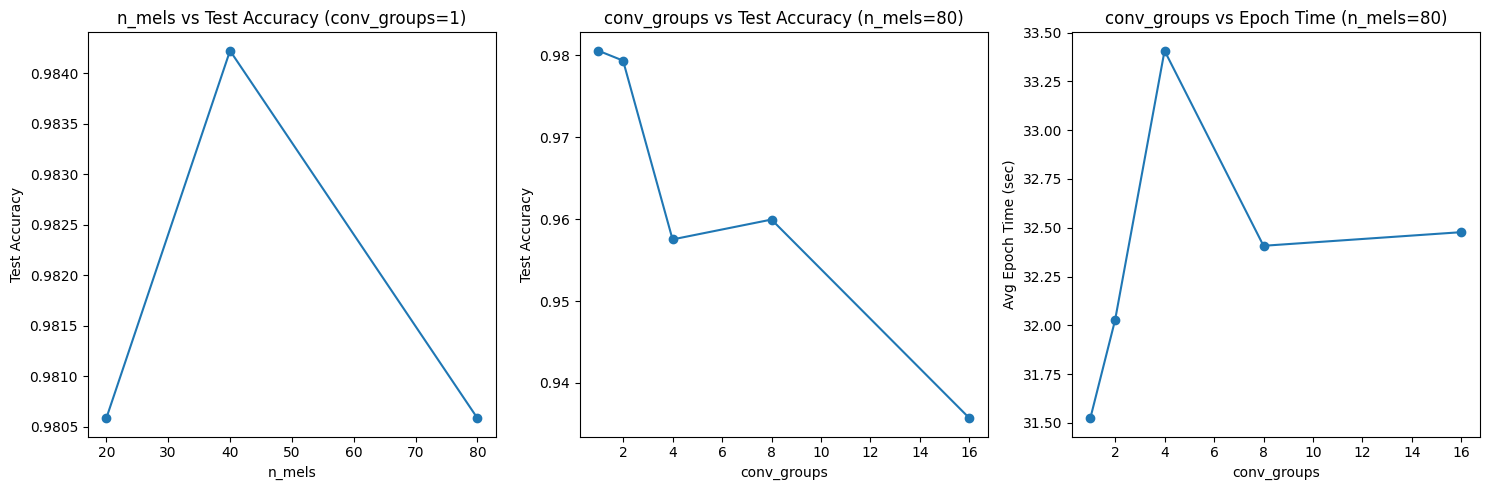

In [49]:
# Собираем результаты в DataFrame и сохраняем в CSV
df_results = pd.DataFrame(results)
print("\nРезультаты экспериментов:")
print(df_results)
df_results.to_csv("experiment_results.csv", index=False)

# Построение графиков для анализа
plt.figure(figsize=(15, 5))

# График: n_mels (при conv_groups = 1) vs. test accuracy
df1 = df_results[df_results["conv_groups"] == 1]
plt.subplot(1, 3, 1)
plt.plot(df1["n_mels"], df1["test_acc"], marker="o")
plt.xlabel("n_mels")
plt.ylabel("Test Accuracy")
plt.title("n_mels vs Test Accuracy (conv_groups=1)")

# График: conv_groups (при n_mels = 80) vs. test accuracy
df2 = df_results[df_results["n_mels"] == 80]
plt.subplot(1, 3, 2)
plt.plot(df2["conv_groups"], df2["test_acc"], marker="o")
plt.xlabel("conv_groups")
plt.ylabel("Test Accuracy")
plt.title("conv_groups vs Test Accuracy (n_mels=80)")

# График: conv_groups (при n_mels = 80) vs. avg epoch time
plt.subplot(1, 3, 3)
plt.plot(df2["conv_groups"], df2["epoch_time_sec"], marker="o")
plt.xlabel("conv_groups")
plt.ylabel("Avg Epoch Time (sec)")
plt.title("conv_groups vs Epoch Time (n_mels=80)")

plt.tight_layout()
plt.show()

In [50]:
!pip freeze > requirements.txt

In [52]:
!pip install thop

In [56]:
# с флопами
from thop import profile

for config in experiment_configs:
    n_mels = config["n_mels"]
    conv_groups = config["conv_groups"]
    print(f"\nЭксперимент: n_mels={n_mels}, conv_groups={conv_groups}")

    model = CNNBinaryClassifier(n_mels=n_mels, conv_groups=conv_groups, lr=1e-3)

    logger = TensorBoardLogger("tb_logs", name=f"model_nmel{n_mels}_cg{conv_groups}")

    trainer = pl.Trainer(
        max_epochs=10,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        logger=logger,
        log_every_n_steps=10
    )

    start_time = time.time()
    trainer.fit(model, data_module)
    epoch_time = (time.time() - start_time) / 10.0

    test_metrics = trainer.test(model, data_module)

    num_params = model.count_parameters()

    flops = model.compute_flops(n_frames=100)

    results.append({
        "n_mels": n_mels,
        "conv_groups": conv_groups,
        "num_params": num_params,
        "flops": flops,
        "epoch_time_sec": epoch_time,
        "test_acc": test_metrics[0]["test_acc"],
        "test_loss": test_metrics[0]["test_loss"]
    })

    print(f"n_mels: {n_mels}, conv_groups: {conv_groups}, params: {num_params}, FLOPs: {flops}, avg epoch time: {epoch_time:.2f} sec")
    print("Test metrics:", test_metrics)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs



Эксперимент: n_mels=20, conv_groups=1


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Train samples: 6358
Validation samples: 803
Test samples: 824


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Train samples: 6358
Validation samples: 803
Test samples: 824


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9381067752838135     │
│         test_loss         │    0.17072586715221405    │
└───────────────────────────┴───────────────────────────┘

n_mels: 80, conv_groups: 16, params: 2817, FLOPs: 262656.0, avg epoch time: 31.99 sec
Test metrics: [{'test_loss': 0.17072586715221405, 'test_acc': 0.9381067752838135}]
